### Load in Data Sets and Merge them together

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns

# Load dataset
netflix = pd.read_csv("C:\\Users\\aj4ho\\my-final-project\\data\\netflix_titles.csv")
imdb = pd.read_csv("C:\\Users\\aj4ho\\my-final-project\\data\\imdb_data.csv")

# extract title and year from imdb dataset
def split_name(x):
    match = re.match(r'(.+)\n\((\d{4})\)', str(x))
    if match:
        return pd.Series([match.group(1), int(match.group(2))])
    return pd.Series([x, None])

imdb[['title','release_year']] = imdb['Name'].apply(split_name)

# keep only needed columns
imdb = imdb[['title','release_year','Rating']]

# clean titles
netflix['title_clean'] = netflix['title'].str.strip()
imdb['title_clean'] = imdb['title'].str.strip()

# merge datasets
df = pd.merge(
    netflix,
    imdb,
    left_on=['title_clean','release_year'],
    right_on=['title_clean','release_year'],
    how='left'
)

df.head()
# View first rows

,show_id,type,title_x,director,cast,country,date_added,release_year,rating,duration,listed_in,description,title_clean,title_y,Rating
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Dick Johnson Is Dead,NaN,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Blood & Water,NaN,NaN
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Ganglands,NaN,NaN
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Jailbirds New Orleans,NaN,NaN
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Kota Factory,NaN,NaN


### Basic Statistics

In [16]:
# number of observations and features
print("Dataset shape:", df.shape)

# data types
print("\nData Types:\n")
print(df.dtypes)

# summary statistics
df.describe(include="all")

Dataset shape: (8860, 15)

Data Types:

show_id             str
type                str
title_x             str
director            str
cast                str
country             str
date_added          str
release_year      int64
rating              str
duration            str
listed_in           str
description         str
title_clean         str
title_y             str
Rating          float64
dtype: object


,show_id,type,title_x,director,cast,country,date_added,release_year,rating,duration,listed_in,description,title_clean,title_y,Rating
count,8860,8860,8860,6226,8032,8029,8850,8860.000000,8856,8857,8860,8860,8860,1892,1892.000000
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775,8806,1839,NaN
top,s7231,Movie,Krish Trish and Baltiboy: Face Your Fears,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,Documentaries,"In three tales about fear, a baby elephant get...",Krish Trish and Baltiboy: Face Your Fears,Krish Trish and Baltiboy: Face Your Fears,NaN
freq,8,6184,8,19,19,2832,113,NaN,3223,1793,362,8,8,8,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.179007,NaN,NaN,NaN,NaN,NaN,NaN,6.233140
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.810635,NaN,NaN,NaN,NaN,NaN,NaN,1.157395
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN,NaN,NaN,5.500000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN,NaN,NaN,6.400000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN,NaN,NaN,7.100000


### Distribution of Target Variable (rating)

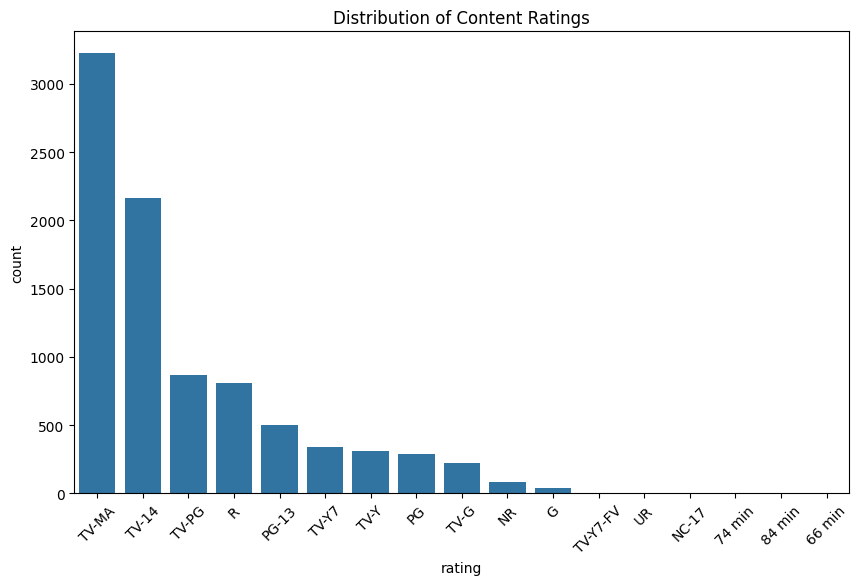

In [20]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="rating", order=df["rating"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Distribution of Content Ratings")
plt.show()

### Missing Value Analysis

In [21]:
missing = df.isnull().sum().sort_values(ascending=False)

print(missing)

title_y         6968
Rating          6968
director        2634
country          831
cast             828
date_added        10
rating             4
duration           3
type               0
title_x            0
show_id            0
listed_in          0
release_year       0
title_clean        0
description        0
dtype: int64


### Visualizations

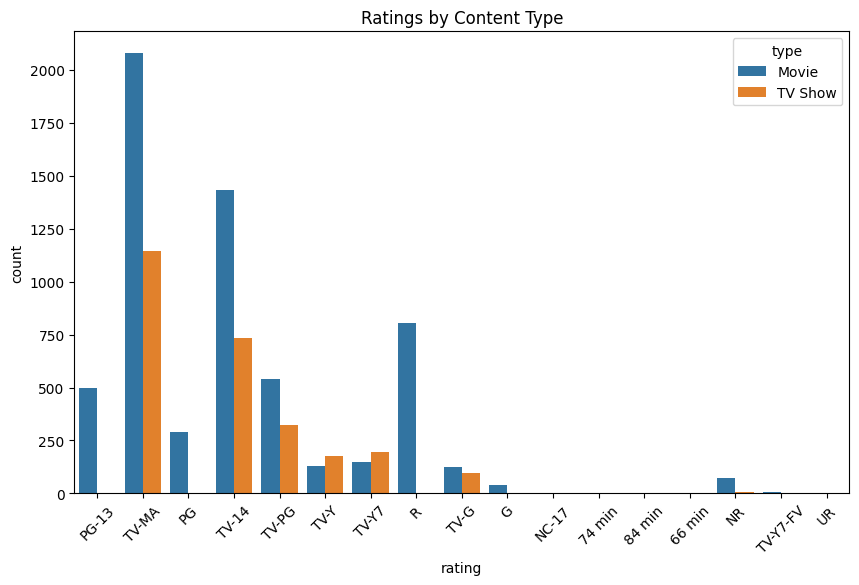

In [22]:
# Rating by Content Type
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="rating", hue="type")
plt.xticks(rotation=45)
plt.title("Ratings by Content Type")
plt.show()

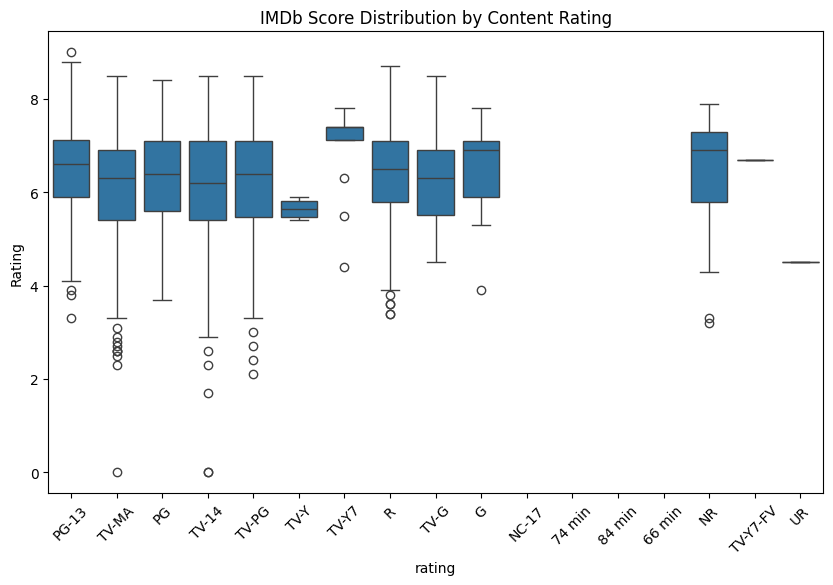

In [33]:
# IMDb Rating vs Content Rating
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="rating", y="Rating")
plt.xticks(rotation=45)
plt.title("IMDb Score Distribution by Content Rating")
plt.show()

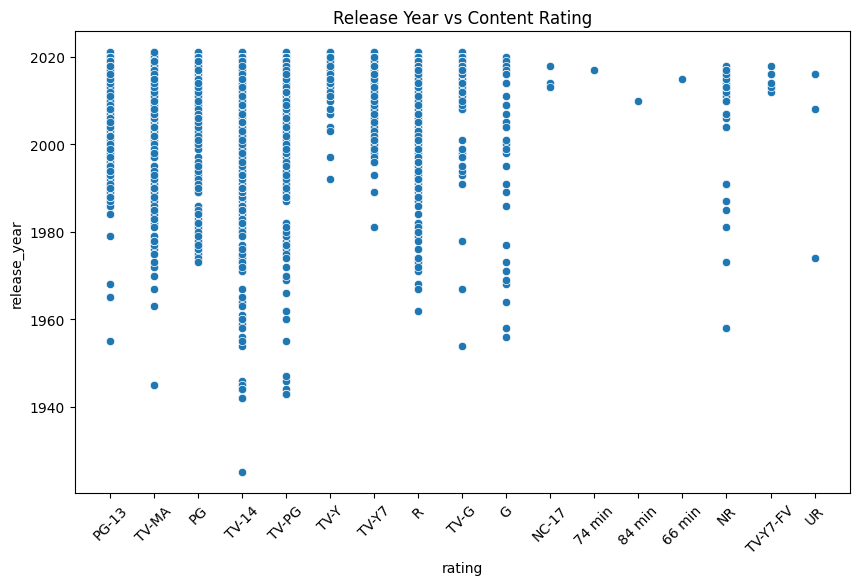

In [28]:
# Release Year vs Rating 
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="rating", y="release_year")
plt.xticks(rotation=45)
plt.title("Release Year vs Content Rating")
plt.show()

### Summary
The dataset contains thousands of Netflix titles with features describing content characteristics such as release year, duration, and genre. The target variable, content rating, is imbalanced with ratings such as TV-MA and TV-14 appearing most frequently. Several of the main features contain missing lots of missing values  which will require preprocessing. Initial visualizations show that rating distributions differ between movies and television shows, suggesting that content type may be an important predictor.

### Feature Engineering

In [34]:
# Create description length feature
df["description_length"] = df["description"].astype(str).apply(len)

Feature description_length counts the number of characters in the content description. It helps because longer descriptions may indicate more complex plots or mature themes that require more detailed summaries. The domain justification is that streaming platforms often provide longer descriptions for complex or mature content aimed at adult audiences.

In [36]:
# Create Genre Count Feature
df["genre_count"] = df["listed_in"].astype(str).apply(lambda x: len(x.split(",")))

Feature genre_count counts how many genres are assigned to a title. It helps because titles with multiple genres may involve more complex themes or content types that influence rating classification. The domain justification is that ratings are often influenced by combinations of genre elements such as violence, horror, or adult themes.

In [38]:
# Create Cast Size Feature
df["cast_count"] = df["cast"].str.split(',').str.len().fillna(0)

Feature cast_count counts the number of actors listed in the cast field. This helps because large productions often have larger casts and may correlate with higher-budget content that targets specific audiences. The domain justification is that production scale and cast size can indirectly reflect content type and target audience.

### Prepare Data for Modeling 

In [49]:
# Select features and target variable
features = [
    "release_year",
    "Rating",
    "description_length",
    "genre_count",
    "cast_count"
]

# Remove rare ratings and keep those that appear at least 20 times
df = df[df["rating"].groupby(df["rating"]).transform("count") >= 20]

X = df[features]
y = df["rating"]

# Handle missing values
X = X.fillna(X.mean())

# Encode target variable
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [51]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

During preprocessing, several rating categories appeared only once in the dataset. Since stratified train/test splitting requires at least two samples per class, rare ratings were removed from the dataset. This step helps ensure stable model training and prevents errors during the stratified split. In addition, the dataset was split into training and testing sets using an 80/20 ratio. Stratified sampling was used for the class of the rating variable. Missing values in numeric features were handled using mean imputation. Feature scaling was applied using StandardScaler to normalize the range of input variables before training the models.

### ML Models

In [ ]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model1 = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    multi_class='auto'
)
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred1))
print(classification_report(y_test, y_pred1))

Accuracy: 0.40101809954751133
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.00      0.00      0.00        16
           2       0.00      0.00      0.00        58
           3       0.00      0.00      0.00       100
           4       0.27      0.17      0.21       162
           5       0.36      0.21      0.26       433
           6       0.00      0.00      0.00        44
           7       0.42      0.92      0.58       645
           8       0.00      0.00      0.00       173
           9       0.00      0.00      0.00        61
          10       0.00      0.00      0.00        68

    accuracy                           0.40      1768
   macro avg       0.09      0.12      0.10      1768
weighted avg       0.26      0.40      0.29      1768



c:\Users\aj4ho\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aj4ho\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aj4ho\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

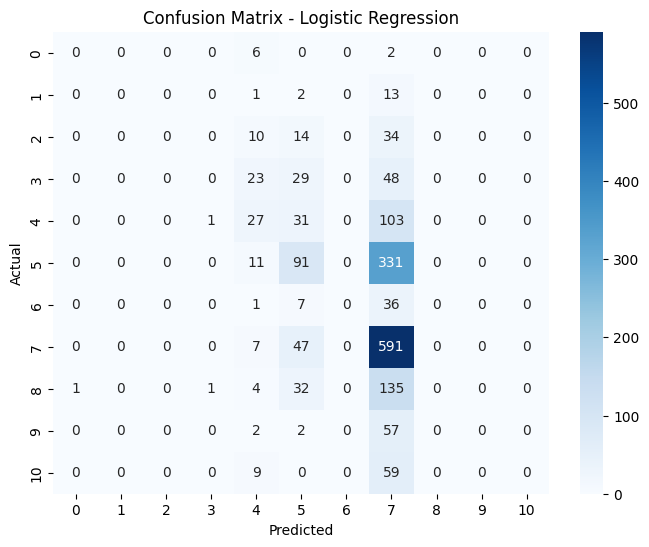

In [55]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred1)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [56]:
# Random Forest 
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred2))
print(classification_report(y_test, y_pred2))

Accuracy: 0.4230769230769231
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.00      0.00      0.00        16
           2       0.17      0.02      0.03        58
           3       0.25      0.17      0.20       100
           4       0.31      0.28      0.30       162
           5       0.38      0.31      0.34       433
           6       0.00      0.00      0.00        44
           7       0.47      0.80      0.59       645
           8       0.35      0.05      0.09       173
           9       0.31      0.28      0.29        61
          10       0.37      0.10      0.16        68

    accuracy                           0.42      1768
   macro avg       0.24      0.18      0.18      1768
weighted avg       0.37      0.42      0.37      1768



c:\Users\aj4ho\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aj4ho\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aj4ho\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

### Comparison Table 

In [57]:
# Model comparison data
comparison_data = {
    "Model": ["Logistic Regression", "Random Forest"],
    
    "Key Hyperparameters": [
        "max_iter=1000, solver='lbfgs'",
        "n_estimators=100, max_depth=10"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred1),
        accuracy_score(y_test, y_pred2)
    ],
    
    "Precision (weighted)": [
        0.26,   # from your logistic report
        0.37    # from your random forest report
    ],
    
    "Recall (weighted)": [
        0.40,
        0.42
    ],
    
    "F1 Score (weighted)": [
        0.29,
        0.37
    ],
    
    "Training Time": [
        "Very Fast",
        "Moderate"
    ],
    
    "Interpretability": [
        "High",
        "Medium"
    ]
}

comparison_df = pd.DataFrame(comparison_data)

comparison_df

,Model,Key Hyperparameters,Accuracy,Precision (weighted),Recall (weighted),F1 Score (weighted),Training Time,Interpretability
0,Logistic Regression,"max_iter=1000, solver='lbfgs'",0.401018,0.26,0.40,0.29,Very Fast,High
1,Random Forest,"n_estimators=100, max_depth=10",0.423077,0.37,0.42,0.37,Moderate,Medium


### Next Steps

To improve model performance, additional engineered features will be created based on patterns observed during exploratory data analysis. Potential features include extracting keywords from the description field that may indicate mature content, such as references to violence, crime, or war. Another potential feature is the number of countries associated with a title, which may reflect production scale and target audiences. Additionally, genre-based indicators could be created to identify whether a title belongs to categories often associated with mature content, such as horror or crime. These new features should provide stronger signals for predicting content ratings and help the model better distinguish between rating categories.

The Random Forest model will be further optimized using hyperparameter tuning techniques such as GridSearchCV or RandomizedSearchCV. Parameters including the number of trees, maximum tree depth, and minimum samples per split will be explored to determine the best-performing configuration. Additional preprocessing techniques may also be applied, such as balancing the dataset using class weighting or resampling methods to address the class imbalance observed in the rating distribution. Testing additional algorithms, such as Gradient Boosting or XGBoost, may also improve performance if they capture patterns that Random Forest cannot.

One area where additional guidance would be helpful is determining whether grouping content ratings into broader categories (for example, Kids, Teen, and Mature) would improve classification performance compared to predicting the full set of ratings. Another question is whether incorporating natural language processing techniques on the description field would significantly strengthen the model. Feedback on additional feature engineering strategies or alternative machine learning algorithms that may be well suited for this dataset would also be appreciated.
